In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
%matplotlib inline
import uproot
import pandas as pd
from vmm_tools import read_cluster, read_hits_in_cluster, read_hits_in_cluster_majd, set_axes_equal, GetTransErrs, Reconstruction3D
import awkward as ak
from scipy.optimize import curve_fit
import matplotlib.cm as cmx
import plotly.graph_objects as go

In [30]:
'''--------------------------MATPLOTLIB PLOT PARAMETERS--------------------------'''

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 16,
    'lines.linewidth': 2,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

In [31]:
'''-----------------------------------FUNCTIONS----------------------------------'''
def fiducializeClusterHits(df_event, area):
    '''if area == 'd':
        xlo, xhi = 156, 217
        ylo, yhi = 280, 342
    elif area == 'c':
        xlo, xhi = 156, 217
        ylo, yhi = 156, 217
    elif area == 'b':
        xlo, xhi = 280, 342
        ylo, yhi = 280, 342
    elif area == 'a':
        xlo, xhi = 280, 342
        ylo, yhi = 156, 217
    else:
        raise Exception("provide valid area")'''
    
    if area == 'd':
        xlo, xhi = 0, 249
        ylo, yhi = 250, 500
    elif area == 'c':
        xlo, xhi = 0, 249
        ylo, yhi = 0, 249
    elif area == 'b':
        xlo, xhi = 250, 500
        ylo, yhi = 250, 500
    elif area == 'a':
        xlo, xhi = 250, 500
        ylo, yhi = 0, 249
    else:
        raise Exception("provide valid area")

    xMask = (df_event['xHits'] >= xlo) & (df_event['xHits'] <= xhi)
    yMask = (df_event['yHits'] >= ylo) & (df_event['yHits'] <= yhi)

    return {
        'xHits':  df_event['xHits'][xMask],
        'xADC':   df_event['xADC'][xMask],
        'xTime':  df_event['xTime'][xMask],
        'yHits':  df_event['yHits'][yMask],
        'yADC':   df_event['yADC'][yMask],
        'yTime':  df_event['yTime'][yMask],
        'cluster_pos0': df_event['cluster_pos0'],
        'cluster_pos1': df_event['cluster_pos1'],
    }

def fiducializeMaxADC(df_max_adc, area):
    '''if area == 'd':
        xlo, xhi = 156, 217
        ylo, yhi = 280, 342
    elif area == 'c':
        xlo, xhi = 156, 217
        ylo, yhi = 156, 217
    elif area == 'b':
        xlo, xhi = 280, 342
        ylo, yhi = 280, 342
    elif area == 'a':
        xlo, xhi = 280, 342
        ylo, yhi = 156, 217
    else:
        raise Exception("provide valid area")'''
    
    if area == 'd':
        xlo, xhi = 0, 249
        ylo, yhi = 250, 500
    elif area == 'c':
        xlo, xhi = 0, 249
        ylo, yhi = 0, 249
    elif area == 'b':
        xlo, xhi = 250, 500
        ylo, yhi = 250, 500
    elif area == 'a':
        xlo, xhi = 250, 500
        ylo, yhi = 0, 249
    else:
        raise Exception("provide valid area")

    xMask = (df_max_adc['strips0'] >= xlo) & (df_max_adc['strips0'] <= xhi)
    yMask = (df_max_adc['strips1'] >= ylo) & (df_max_adc['strips1'] <= yhi)
    mask = xMask & yMask

    return {
        'strips0': df_max_adc['strips0'][mask],
        'adcs0':   df_max_adc['adcs0'][mask],
        'times0':  df_max_adc['times0'][mask],
        'strips1': df_max_adc['strips1'][mask],
        'adcs1':   df_max_adc['adcs1'][mask],
        'times1':  df_max_adc['times1'][mask],
    }

def gaussian(x, amp, mean, std):
    return amp * np.exp(-0.5 * ((x - mean) / std) ** 2)

In [32]:
'''-----------------------------PARAMETERS (edit here)----------------------------'''
strip_edges = np.arange(-0.5,499.5,1.0)

#colors for the histograms, if plotting more than 8 datasets overlaid, add more colors
hist_colors = ['#0077BB', '#EE7733', '#009988', '#EE3377', '#BBBBBB', '#000000', '#33BBEE', '#CC3311']

filename = 'mesh_voltage_test/750V_lowerthreshold/750V.root'
event_id= 11191
gain_x, gain_y = 9.0, 4.5 #mV/fC
label = f'Event {event_id}'

In [33]:
'''-----------------------------------FETCH DATA----------------------------------'''

df_hits = read_hits_in_cluster(filename)
df_cluster = read_cluster(filename)

max_x_adc_idx = ak.argmax(df_hits['adcs0'], axis=1, keepdims=True)
max_y_adc_idx = ak.argmax(df_hits['adcs1'], axis=1, keepdims=True)

df_max_adc = {
    'strips0': ak.flatten(df_hits['strips0'][max_x_adc_idx]),
    'adcs0':   ak.flatten(df_hits['adcs0'][max_x_adc_idx]),
    'times0':  ak.flatten(df_hits['times0'][max_x_adc_idx]),

    'strips1': ak.flatten(df_hits['strips1'][max_y_adc_idx]),
    'adcs1':   ak.flatten(df_hits['adcs1'][max_y_adc_idx]),
    'times1':  ak.flatten(df_hits['times1'][max_y_adc_idx]),
}

min_T = min(min(df_max_adc['times0']), min(df_max_adc['times1']))
df_max_adc['times0'] = df_max_adc['times0'] - min_T
df_max_adc['times1'] = df_max_adc['times1'] - min_T

df_max_adc_fid_a = fiducializeMaxADC(df_max_adc, 'a')
df_max_adc_fid_b = fiducializeMaxADC(df_max_adc, 'b')
df_max_adc_fid_c = fiducializeMaxADC(df_max_adc, 'c')
df_max_adc_fid_d = fiducializeMaxADC(df_max_adc, 'd')

df_event = {
    'xHits': df_hits['strips0'][event_id],
    'yHits': df_hits['strips1'][event_id],
    'xADC': df_hits['adcs0'][event_id],
    'yADC': df_hits['adcs1'][event_id],
    'xTime': df_hits['times0'][event_id],
    'yTime': df_hits['times1'][event_id],
    'cluster_pos0': df_cluster['pos0'][event_id],
    'cluster_pos1': df_cluster['pos1'][event_id],
}

min_T = min(min(df_event['xTime']), min(df_event['yTime']))
df_event['xTime'] = df_event['xTime'] - min_T
df_event['yTime'] = df_event['yTime'] - min_T

df_event_fid_a = fiducializeClusterHits(df_event, 'a')
df_event_fid_b = fiducializeClusterHits(df_event, 'b')
df_event_fid_c = fiducializeClusterHits(df_event, 'c')
df_event_fid_d = fiducializeClusterHits(df_event, 'd')

regions = {'a': df_event_fid_a, 'b': df_event_fid_b, 'c': df_event_fid_c, 'd': df_event_fid_d}

contained = [area for area, df in regions.items() if len(df['xHits']) > 0 and len(df['yHits']) > 0]

if len(contained) == 1:
    region = contained[0]
    print(f"Cluster contained in region {region}")
else:
    print("Cluster not contained in a single region")


Cluster contained in region a


[1281, 1285, 1288, 1290, 1454, 1553, ..., 11142, 11191, 11543, 11883, 11902]
66


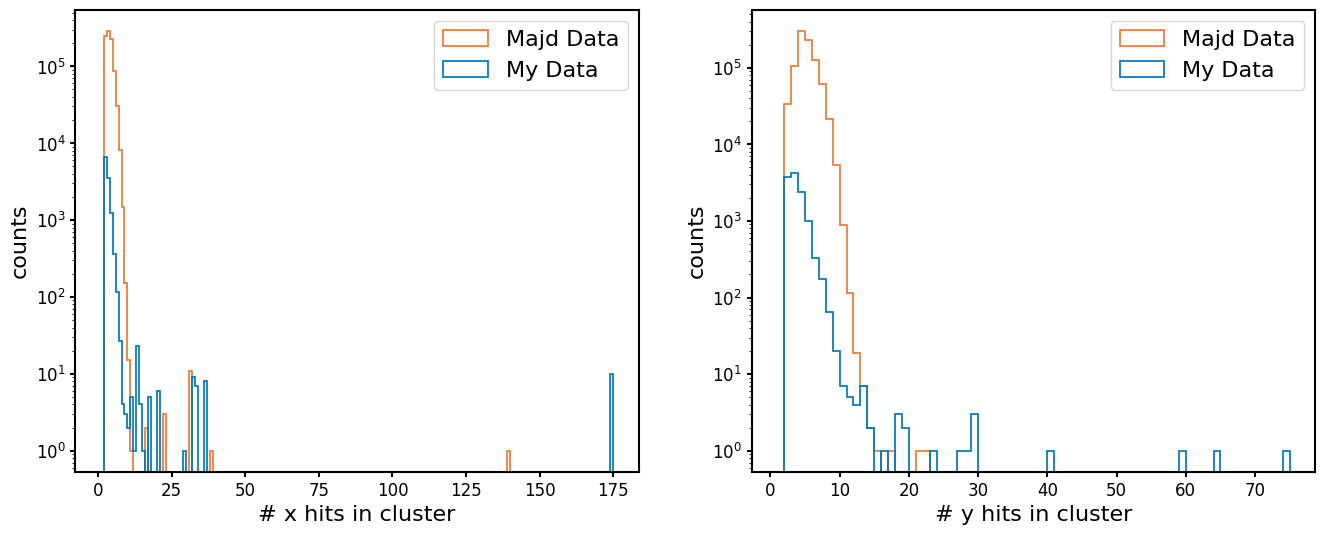

In [ ]:
'''NUM HITS IN CLUSTER (Mine and Majd Overlaid)'''

numXHits = ak.num(df_hits['strips0'])
numYHits = ak.num(df_hits['strips1'])

'''lower_bound = 5
upper_bound = 25
where_events = np.where((numXHits > lower_bound) & (numYHits > lower_bound) & (numXHits < upper_bound) & (numYHits < upper_bound))[0]
print(where_events)
print(len(where_events))'''

df_hits_majd = read_hits_in_cluster_majd(r'Majd_data\690Vmesh_bc_40p000_tac_60_ccs_4_cs_2_dt_200_mst_1_spc_1500_dp_200_cr_0p00-1000p00_coin_center-of-mass_test.root')
numXHitsMajd = ak.num(df_hits_majd['strips0'])
numYHitsMajd = ak.num(df_hits_majd['strips1'])

logscale = True

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

bins_x = np.arange(1, np.max(numXHits) + 1)
bins_y = np.arange(1, np.max(numYHits) + 1)

bins_x_Majd = np.arange(1, np.max(numXHitsMajd) + 1)
bins_y_Majd = np.arange(1, np.max(numYHitsMajd) + 1)

x_counts_Majd, x_bin_edges_Majd, x_patches_Majd = ax[0].hist(numXHitsMajd, bins=bins_x_Majd,histtype='step', color=hist_colors[1], linewidth=1.25, label="Majd Data")
y_counts_Majd, y_bin_edges_Majd, y_patches_Majd = ax[1].hist(numYHitsMajd, bins=bins_y_Majd, histtype='step', color=hist_colors[1], linewidth=1.25, label="Majd Data")

x_counts, x_bin_edges, x_patches = ax[0].hist(numXHits, bins=bins_x,histtype='step', color=hist_colors[0], linewidth=1.25, label="My Data")
y_counts, y_bin_edges, y_patches = ax[1].hist(numYHits, bins=bins_y, histtype='step', color=hist_colors[0], linewidth=1.25, label="My Data")

ax[0].legend(loc='upper right')
ax[0].set_xlabel("# x hits in cluster")
ax[0].set_ylabel("counts")
ax[1].legend(loc='upper right')
ax[1].set_xlabel("# y hits in cluster")
ax[1].set_ylabel("counts")

if logscale == True:
    ax[0].set_yscale("log")
    ax[1].set_yscale("log")

#ax[0].set_ylim(0, 10)
#ax[1].set_ylim(0, 10)

fig.savefig(f'plots/png/num_xy_hits_in_clusters.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/num_xy_hits_in_clusters.pdf', bbox_inches="tight")


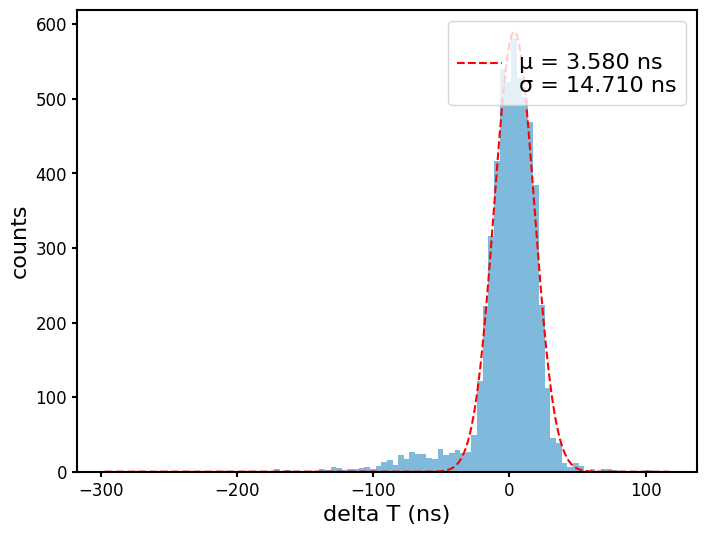

In [35]:
'''-------------------------------deltaT------------------------------'''
logscale = False
num_bins = 100

deltaT = df_max_adc_fid_a['times0'] - df_max_adc_fid_a['times1']

fig, ax = plt.subplots(figsize=(8, 6))

counts, bin_edges, patches = ax.hist(deltaT, bins=num_bins, color=hist_colors[0], linewidth=1.25, alpha=0.5)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=[counts.max(), ak.mean(deltaT), ak.std(deltaT)])
ampT, meanT, stdT = popt

x_fit = np.linspace(bin_edges[0], bin_edges[-1], 1000)
ax.plot(x_fit, gaussian(x_fit, *popt), color='red', linewidth=1.5, linestyle='--', label=f'\nμ = {meanT:.3f} ns\nσ = {stdT:.3f} ns')

ax.legend(loc='upper right')
ax.set_xlabel("delta T (ns)")
ax.set_ylabel("counts")

if logscale == True:
    ax.set_yscale("log")

#ax[0].set_ylim(0, 10)
#ax[1].set_ylim(0, 10)

fig.savefig(f'plots/png/max_charge_deltaT_dist.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/max_charge_deltaT_dist.pdf', bbox_inches="tight")

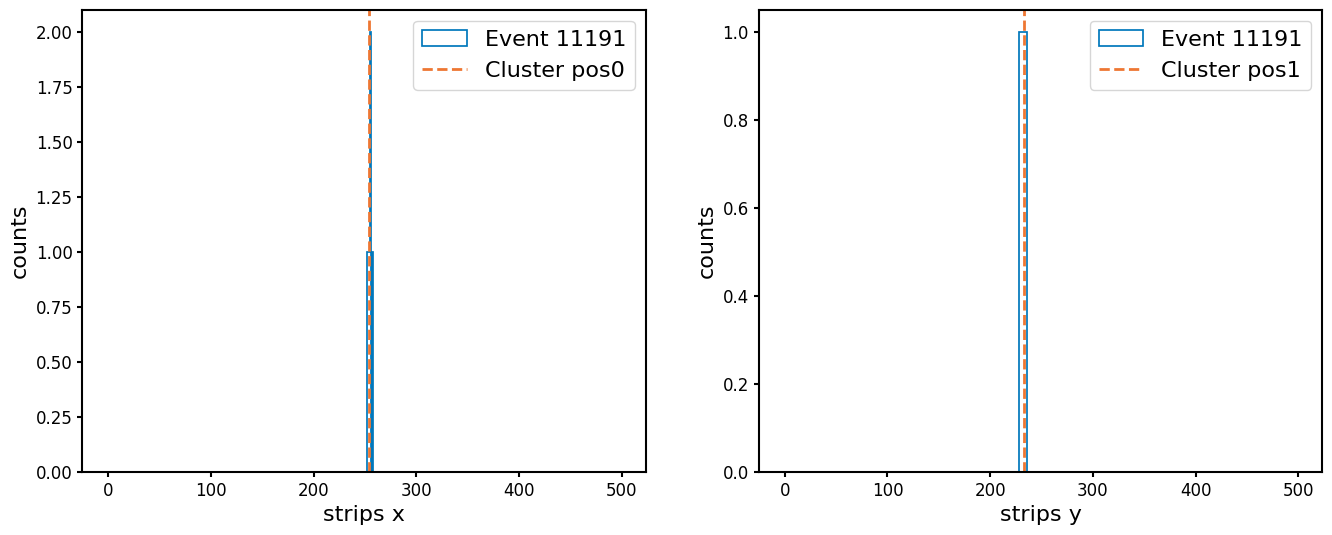

In [36]:
'''-------------------------------HIT RECONSTRUCTION------------------------------'''
logscale = False

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

x_counts, x_bin_edges, x_patches = ax[0].hist(df_event['xHits'], bins=strip_edges, histtype='step', color=hist_colors[0], linewidth=1.25, label=label)
y_counts, y_bin_edges, y_patches = ax[1].hist(df_event['yHits'], bins=strip_edges, histtype='step', color=hist_colors[0], linewidth=1.25, label=label)

ax[0].axvline(df_event['cluster_pos0'], color=hist_colors[1], linestyle='--', label='Cluster pos0')
ax[1].axvline(df_event['cluster_pos1'], color=hist_colors[1], linestyle='--', label='Cluster pos1')

ax[0].legend(loc='upper right')
ax[0].set_xlabel("strips x")
ax[0].set_ylabel("counts")
ax[1].legend(loc='upper right')
ax[1].set_xlabel("strips y")
ax[1].set_ylabel("counts")

if logscale == True:
    ax[0].set_yscale("log")
    ax[1].set_yscale("log")

#ax[0].set_ylim(0, 10)
#ax[1].set_ylim(0, 10)

fig.savefig(f'plots/png/event_hit_reco.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/event_hit_reco.pdf', bbox_inches="tight")

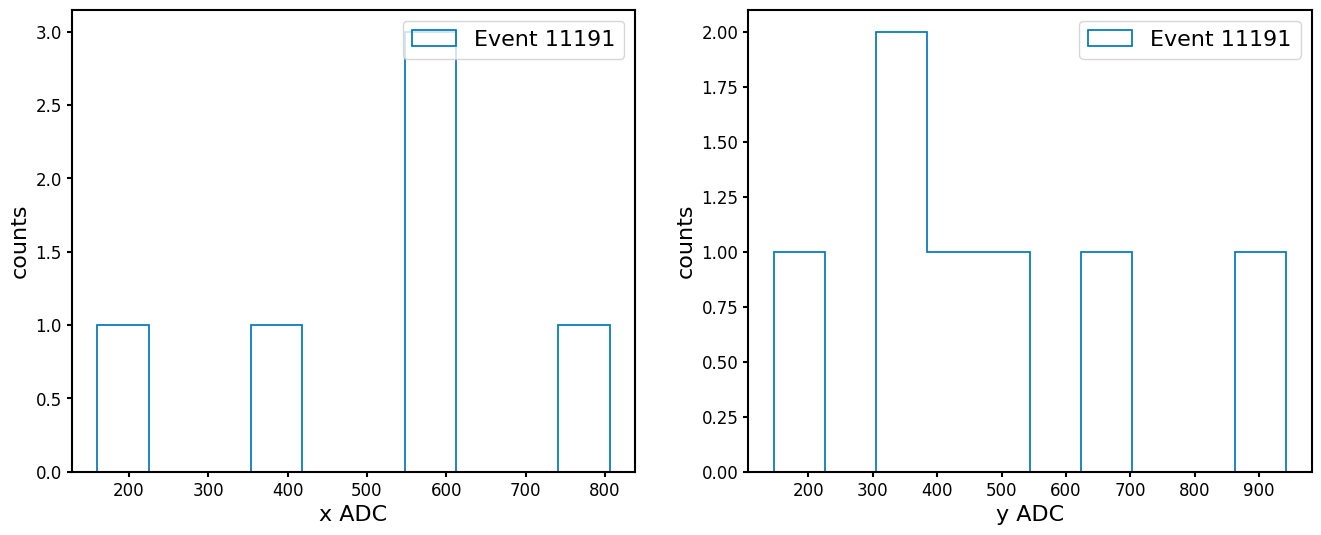

In [37]:
'''-------------------------------ADC RECONSTRUCTION------------------------------'''
logscale = False

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

x_counts, x_bin_edges, x_patches = ax[0].hist(df_event['xADC'], histtype='step', color=hist_colors[0], linewidth=1.25, label=label)
y_counts, y_bin_edges, y_patches = ax[1].hist(df_event['yADC'], histtype='step', color=hist_colors[0], linewidth=1.25, label=label)

ax[0].legend(loc='upper right')
ax[0].set_xlabel("x ADC")
ax[0].set_ylabel("counts")
ax[1].legend(loc='upper right')
ax[1].set_xlabel("y ADC")
ax[1].set_ylabel("counts")

if logscale == True:
    ax[0].set_yscale("log")
    ax[1].set_yscale("log")

#ax[0].set_ylim(0, 10)
#ax[1].set_ylim(0, 10)

fig.savefig(f'plots/png/event_adc_reco.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/event_adc_reco.pdf', bbox_inches="tight")

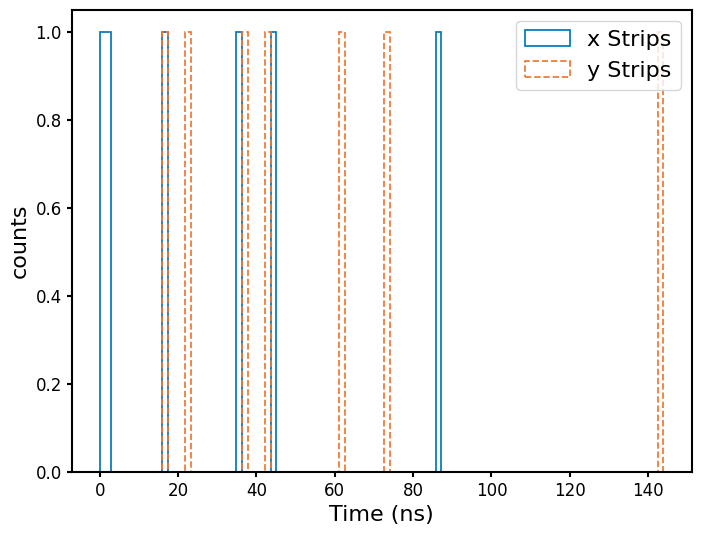

In [38]:
'''-------------------------------TIME RECONSTRUCTION------------------------------'''
logscale = False
num_bins = 100

fig, ax = plt.subplots(figsize=(8, 6))

combined_min = min(min(df_event['xTime']), min(df_event['yTime']))
combined_max = max(max(df_event['xTime']), max(df_event['yTime']))
bins = np.linspace(combined_min, combined_max, num_bins)

x_counts, x_bin_edges, x_patches = ax.hist(df_event['xTime'], bins=bins, histtype='step', color=hist_colors[0], linewidth=1.25, label='x Strips')
y_counts, y_bin_edges, y_patches = ax.hist(df_event['yTime'], bins=bins, histtype='step', color=hist_colors[1], linestyle='--', linewidth=1.25, label='y Strips')

ax.legend(loc='upper right')
ax.set_xlabel("Time (ns)")
ax.set_ylabel("counts")

if logscale == True:
    ax.set_yscale("log")
    ax.set_yscale("log")

#ax.set_ylim(0, 10)
#ax.set_ylim(0, 10)

fig.savefig(f'plots/png/event_time_reco.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/event_time_reco.pdf', bbox_inches="tight")

In [39]:
'''------------------------RECONSTRUCTION PARAMATER & DATA FETCH-----------------------'''
mu, sigma, n_sigma = meanT, stdT, 3

pitch_x, pitch_y = 200, 200 #um
v_drift = 8.0 #um/s
n_strips_x, n_strips_y = 500, 500

times_x = np.array(df_event['xTime'])
times_y = np.array(df_event['yTime'])

ADC_x = np.array(df_event['xADC'])
ADC_y = np.array(df_event['yADC'])

strips_x = np.array(df_event['xHits'])
strips_y = np.array(df_event['yHits'])

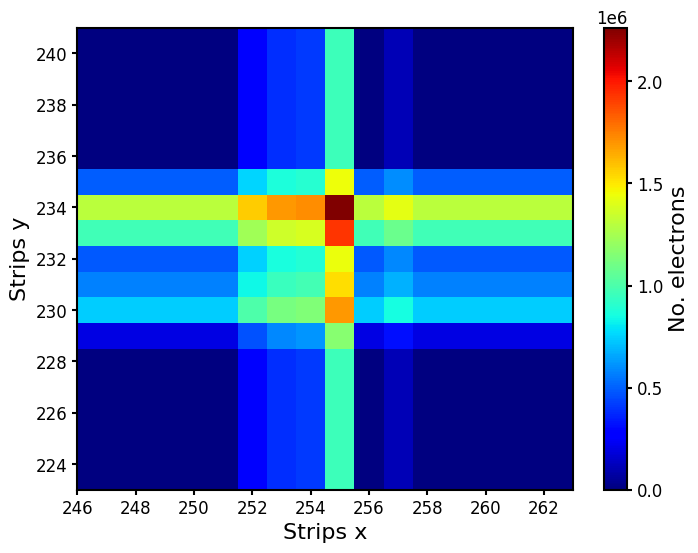

In [40]:
'''-------------------------------2D RECONSTRUCTION------------------------------'''
# Define empty arrays to store 2D histogram information
x_vals = np.array([],dtype=int)
y_vals = np.array([],dtype=int)
weights = np.array([])

# Loop through x strip data
for x_hit,adc_x in zip(strips_x,ADC_x):
    
    x_vals = np.append( x_vals, np.ones(n_strips_y,dtype=int)*x_hit )
    y_vals = np.append( y_vals, np.arange(n_strips_y) )
    weights = np.append(weights, np.ones(n_strips_y,dtype=int)*(6240*adc_x / gain_x) )
    
# Loop through y strip data
for y_hit,adc_y in zip(strips_y,ADC_y):
    
    x_vals = np.append( x_vals, np.arange(n_strips_x) )
    y_vals = np.append( y_vals, np.ones(n_strips_x,dtype=int)*y_hit )
    weights = np.append(weights, np.ones(n_strips_x,dtype=int)*(6240*adc_y / gain_y) )

# Plot the 2D histogram
fig, ax = plt.subplots(figsize=(8, 6))
hist, xedges, yedges, im = ax.hist2d(x_vals, y_vals, bins=[strip_edges,strip_edges], weights=weights, cmap=plt.cm.jet)
fig.colorbar(im, label="No. electrons")
ax.set_xlabel("Strips x")
ax.set_ylabel("Strips y")
        
Mrange = max(max(strips_x)-min(strips_x), max(strips_y)-min(strips_y) )
xmin = min(strips_x)- Mrange
xmax = max(strips_x)+ Mrange
ymin = min(strips_y)- Mrange
ymax = max(strips_y)+ Mrange
ax.axis([xmin, xmax, ymin, ymax]) #uncomment to zoom in on event

fig.savefig(f'plots/png/2d_recon_event.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/2d_recon_event.pdf', bbox_inches="tight")

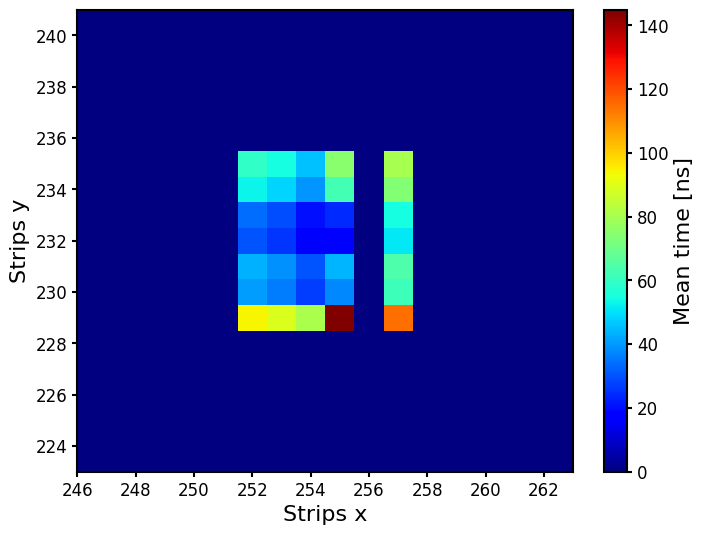

In [41]:
'''----------------------------2D TIME RECONSTRUCTION---------------------------'''
# Define empty arrays to store 2D histogram information
x_vals = np.array([],dtype=int)
y_vals = np.array([],dtype=int)
weights = np.array([])

# Loop through x strip data
for x_hit,time_x in zip(strips_x,times_x):
    for y_hit,time_y in zip(strips_y,times_y):

        x_vals = np.append( x_vals, x_hit )
        y_vals = np.append( y_vals, y_hit )
        weights = np.append(weights, (time_x+time_y)/2.0 )

# Plot the 2D histogram
fig, ax = plt.subplots(figsize=(8, 6))
hist, xedges, yedges, im = ax.hist2d(x_vals, y_vals, bins=[strip_edges,strip_edges], weights=weights, cmap=plt.cm.jet)
fig.colorbar(im, label="Mean time [ns]")
ax.set_xlabel("Strips x")
ax.set_ylabel("Strips y")

Mrange = max(max(strips_x)-min(strips_x), max(strips_y)-min(strips_y) )
xmin = min(strips_x)- Mrange
xmax = max(strips_x)+ Mrange
ymin = min(strips_y)- Mrange
ymax = max(strips_y)+ Mrange
ax.axis([xmin, xmax, ymin, ymax]) #uncomment to zoom in on event

fig.savefig(f'plots/png/2d_time_recon_event.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/2d_time_recon_event.pdf', bbox_inches="tight")

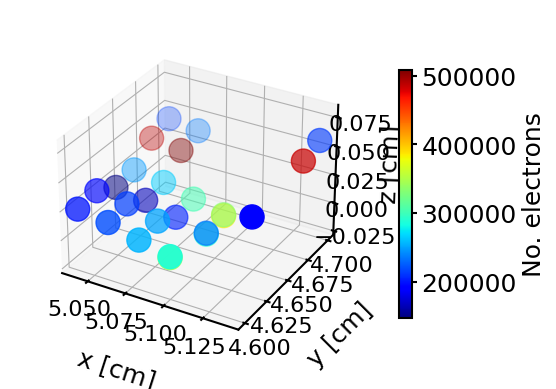

In [42]:
'''-------------------------------3D RECONSTRUCTION------------------------------'''
x_vals, y_vals, z_vals, weights = Reconstruction3D(mu, sigma, n_sigma, times_x, times_y, ADC_x, ADC_y, strips_x, strips_y, gain_x, gain_y, pitch_x, pitch_y, v_drift)

# Plot the 3D scatter
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

#set color map
cm = plt.get_cmap('jet')
'''cNorm = Normalize(vmin=250000, vmax=650000)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cm)'''
scalarMap = cmx.ScalarMappable(cmap=cm)

ax.scatter(x_vals*1e-4, y_vals*1e-4, z_vals*1e-4, c=scalarMap.to_rgba(weights),s=300)
scalarMap.set_array(weights)
cbar = fig.colorbar(scalarMap, ax=ax, fraction=0.025, pad=0.04)
cbar.ax.tick_params(labelsize=18)
cbar.set_label(label='No. electrons',size=18)

set_axes_equal(ax)

# Set labels
ax.set_xlabel('x [cm]',labelpad = 20,fontsize=18)
ax.set_ylabel('y [cm]',labelpad = 20,fontsize=18)
ax.set_zlabel('z [cm]',labelpad = 7,fontsize=18)
ax.tick_params(labelsize=16)
ax.set_box_aspect(None, zoom=0.85)
fig.savefig(f'plots/png/3d_recon_event.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/3d_recon_event.pdf', bbox_inches="tight")

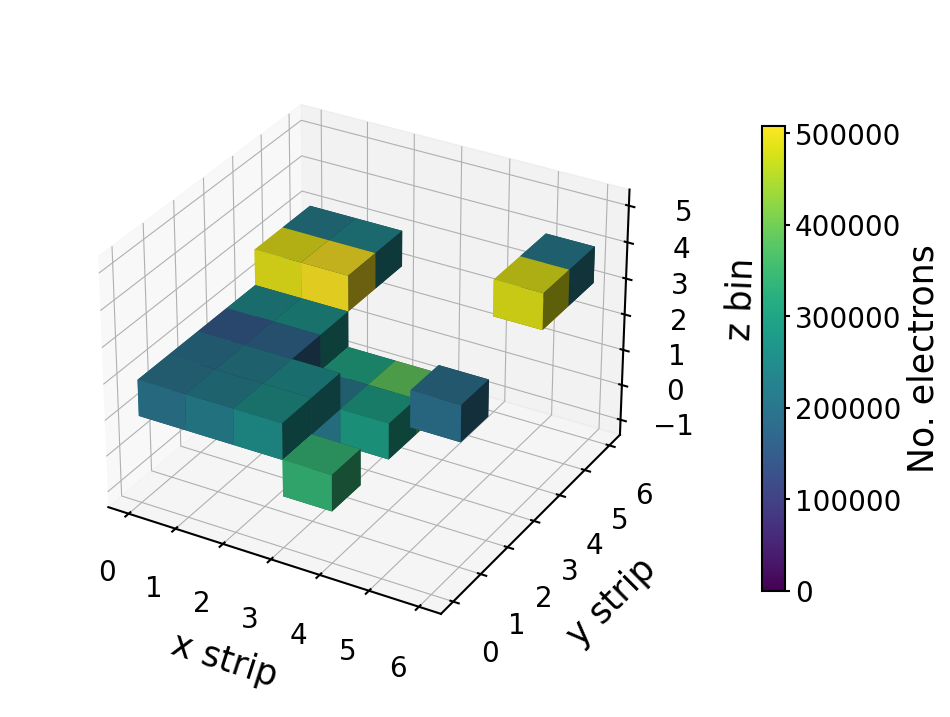

In [43]:
'''-------------------------------3D VOXEL RECONSTRUCTION------------------------------'''
x, y, z, c = Reconstruction3D(mu, sigma, n_sigma, times_x, times_y, ADC_x, ADC_y, strips_x, strips_y, gain_x, gain_y, pitch_x, pitch_y, v_drift)
z_vals, delta_xs_1, delta_ys_1, delta_xs_2, delta_ys_2, v_PA, x_b = GetTransErrs(x,y,z,c, charge_weighting = True)

# Find initial t parameter to draw principal axis
ti = -x_b[2]/v_PA[2]

# Find final parameter to draw principal axis
tf=(np.max(z)-x_b[2])/v_PA[2]

# Start and stop point of fitted line
start = x_b + (ti*v_PA)
stop = x_b + (tf*v_PA)

# transform coord
xi = (start[0]-np.min(x))/200 
yi = (start[1]-np.min(y))/200
zi = (start[2]-np.min(z))/200

xf = (stop[0]-np.min(x))/200 
yf = (stop[1]-np.min(y))/200
zf = (stop[2]-np.min(z))/200

x = np.round((x-np.min(x))/200).astype(int)
y = np.round((y-np.min(y))/200).astype(int)
z = np.round((z-np.min(z))/200).astype(int)

# Empty array to store tensor
tensor = np.zeros(shape=(np.max(x)+1,np.max(y)+1,np.max(z)+1))

# Loop through track and update tensor
for xj, yj, zj, cj in zip(x,y,z,c):
    tensor[xj][yj][zj] = cj

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')

ax.set_xlabel('x strip',labelpad = 40,fontsize=25)
ax.set_ylabel('y strip',labelpad = 40,fontsize=25)
ax.set_zlabel('z bin',labelpad = 40,fontsize=25)
ax.tick_params(labelsize=20)
ax.tick_params(direction='out', pad=20)
ax.set_box_aspect(None, zoom=0.85)

cmap = plt.get_cmap("viridis")
norm= plt.Normalize(0.0, np.max(tensor))

ax.voxels(tensor,facecolors=cmap(norm(tensor)),alpha=1)

#ax.plot([xi,xf], [yi,yf], [zi,zf], color='k')

m = cmx.ScalarMappable(cmap=cmap, norm=norm)
m.set_array([])
cbar = plt.colorbar(m,fraction=0.03, ax=ax, pad=0.07)
cbar.set_label(label='No. electrons',size=25)
cbar.ax.tick_params(labelsize=20)

set_axes_equal(ax)
#ax.set_zlim3d([0, 4])

fig.savefig(f'plots/png/3d_voxels_recon_event.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/3d_voxels_recon_event.pdf', bbox_inches="tight")

In [44]:
'''df_hits = read_hits_in_cluster(filename)
df_cluster = read_cluster(filename)

def get_event(event_id):
    df_event = {
        'xHits': df_hits['strips0'][event_id],
        'yHits': df_hits['strips1'][event_id],
        'xADC': df_hits['adcs0'][event_id],
        'yADC': df_hits['adcs1'][event_id],
        'xTime': df_hits['times0'][event_id],
        'yTime': df_hits['times1'][event_id],
        'cluster_pos0': df_cluster['pos0'][event_id],
        'cluster_pos1': df_cluster['pos1'][event_id],
    }

    min_T = min(min(df_event['xTime']), min(df_event['yTime']))
    df_event['xTime'] = df_event['xTime'] - min_T
    df_event['yTime'] = df_event['yTime'] - min_T

    df_event_fid_a = fiducializeClusterHits(df_event, 'a')
    df_event_fid_b = fiducializeClusterHits(df_event, 'b')
    df_event_fid_c = fiducializeClusterHits(df_event, 'c')
    df_event_fid_d = fiducializeClusterHits(df_event, 'd')

    regions = {'a': df_event_fid_a, 'b': df_event_fid_b, 'c': df_event_fid_c, 'd': df_event_fid_d}

    contained = [area for area, df in regions.items() if len(df['xHits']) > 0 and len(df['yHits']) > 0]

    if len(contained) == 1:
        region = contained[0]
        if region == 'a':
            return df_event
        else:
            return False
    else:
        return False


def plot_the_event(event_id, mu, sigma, n_sigma, times_x, times_y, ADC_x, ADC_y, strips_x, strips_y, gain_x, gain_y, pitch_x, pitch_y, v_drift):
    x, y, z, c = Reconstruction3D(mu, sigma, n_sigma, times_x, times_y, ADC_x, ADC_y, strips_x, strips_y, gain_x, gain_y, pitch_x, pitch_y, v_drift)
    z_vals, delta_xs_1, delta_ys_1, delta_xs_2, delta_ys_2, v_PA, x_b = GetTransErrs(x,y,z,c, charge_weighting = True)

    # Find initial t parameter to draw principal axis
    ti = -x_b[2]/v_PA[2]

    # Find final parameter to draw principal axis
    tf=(np.max(z)-x_b[2])/v_PA[2]

    # Start and stop point of fitted line
    start = x_b + (ti*v_PA)
    stop = x_b + (tf*v_PA)

    # transform coord
    xi = (start[0]-np.min(x))/200 
    yi = (start[1]-np.min(y))/200
    zi = (start[2]-np.min(z))/200

    xf = (stop[0]-np.min(x))/200 
    yf = (stop[1]-np.min(y))/200
    zf = (stop[2]-np.min(z))/200

    x = np.round((x-np.min(x))/200).astype(int)
    y = np.round((y-np.min(y))/200).astype(int)
    z = np.round((z-np.min(z))/200).astype(int)

    # Empty array to store tensor
    tensor = np.zeros(shape=(np.max(x)+1,np.max(y)+1,np.max(z)+1))

    # Loop through track and update tensor
    for xj, yj, zj, cj in zip(x,y,z,c):
        tensor[xj][yj][zj] = cj

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection='3d')

    ax.set_xlabel('x strip',labelpad = 40,fontsize=25)
    ax.set_ylabel('y strip',labelpad = 40,fontsize=25)
    ax.set_zlabel('z bin',labelpad = 40,fontsize=25)
    ax.tick_params(labelsize=20)
    ax.tick_params(direction='out', pad=20)
    ax.set_box_aspect(None, zoom=0.85)

    cmap = plt.get_cmap("viridis")
    norm= plt.Normalize(0.0, np.max(tensor))

    ax.voxels(tensor,facecolors=cmap(norm(tensor)),alpha=1)

    #ax.plot([xi,xf], [yi,yf], [zi,zf], color='k')

    m = cmx.ScalarMappable(cmap=cmap, norm=norm)
    m.set_array([])
    cbar = plt.colorbar(m,fraction=0.03, ax=ax, pad=0.07)
    cbar.set_label(label='No. electrons',size=25)
    cbar.ax.tick_params(labelsize=20)

    set_axes_equal(ax)
    #ax.set_zlim3d([0, 4])

    fig.suptitle(f'Event {event_id}', fontsize=28, y=0.95)

    fig.savefig(f'plots/test/3d_voxels_recon_event_{event_id}.png', bbox_inches="tight")

for i in range(0, len(df_hits['strips0'])):
    event = get_event(i)
    if event is not False:
        try:
            print(f"Plotting event {i}")

            times_x = np.array(event['xTime'])
            times_y = np.array(event['yTime'])
            ADC_x = np.array(event['xADC'])
            ADC_y = np.array(event['yADC'])
            strips_x = np.array(event['xHits'])
            strips_y = np.array(event['yHits'])
            
            plot_the_event(i, mu, sigma, n_sigma, times_x, times_y, ADC_x, ADC_y, strips_x, strips_y, gain_x, gain_y, pitch_x, pitch_y, v_drift)
        except Exception as e:
            print(f"Failed on event {i}: {e}")'''

'df_hits = read_hits_in_cluster(filename)\ndf_cluster = read_cluster(filename)\n\ndef get_event(event_id):\n    df_event = {\n        \'xHits\': df_hits[\'strips0\'][event_id],\n        \'yHits\': df_hits[\'strips1\'][event_id],\n        \'xADC\': df_hits[\'adcs0\'][event_id],\n        \'yADC\': df_hits[\'adcs1\'][event_id],\n        \'xTime\': df_hits[\'times0\'][event_id],\n        \'yTime\': df_hits[\'times1\'][event_id],\n        \'cluster_pos0\': df_cluster[\'pos0\'][event_id],\n        \'cluster_pos1\': df_cluster[\'pos1\'][event_id],\n    }\n\n    min_T = min(min(df_event[\'xTime\']), min(df_event[\'yTime\']))\n    df_event[\'xTime\'] = df_event[\'xTime\'] - min_T\n    df_event[\'yTime\'] = df_event[\'yTime\'] - min_T\n\n    df_event_fid_a = fiducializeClusterHits(df_event, \'a\')\n    df_event_fid_b = fiducializeClusterHits(df_event, \'b\')\n    df_event_fid_c = fiducializeClusterHits(df_event, \'c\')\n    df_event_fid_d = fiducializeClusterHits(df_event, \'d\')\n\n    regions 

In [45]:
'''-------------------------------3D VOXEL RECONSTRUCTION INTERACTIVE (VIBE CODED)------------------------------'''
x, y, z, c = Reconstruction3D(mu, sigma, n_sigma, times_x, times_y, ADC_x, ADC_y, strips_x, strips_y, gain_x, gain_y, pitch_x, pitch_y, v_drift)
z_vals, delta_xs_1, delta_ys_1, delta_xs_2, delta_ys_2, v_PA, x_b = GetTransErrs(x,y,z,c, charge_weighting = True)

# Find initial t parameter to draw principal axis
ti = -x_b[2]/v_PA[2]

# Find final parameter to draw principal axis
tf=(np.max(z)-x_b[2])/v_PA[2]

# Start and stop point of fitted line
start = x_b + (ti*v_PA)
stop = x_b + (tf*v_PA)

# transform coord
xi = (start[0]-np.min(x))/200 
yi = (start[1]-np.min(y))/200
zi = (start[2]-np.min(z))/200

xf = (stop[0]-np.min(x))/200 
yf = (stop[1]-np.min(y))/200
zf = (stop[2]-np.min(z))/200

x = np.round((x-np.min(x))/200).astype(int)
y = np.round((y-np.min(y))/200).astype(int)
z = np.round((z-np.min(z))/200).astype(int)

# Empty array to store tensor
tensor = np.zeros(shape=(np.max(x)+1,np.max(y)+1,np.max(z)+1))

# Loop through track and update tensor
for xj, yj, zj, cj in zip(x,y,z,c):
    tensor[xj][yj][zj] = cj

# Get filled voxel positions and their charge values
xi_v, yi_v, zi_v = np.where(tensor > 0)
charge_vals = tensor[xi_v, yi_v, zi_v]
cmin, cmax = charge_vals.min(), charge_vals.max()

def make_cube_mesh(x, y, z, color, colorscale, cmin, cmax, showscale=False):
    """Returns a Mesh3d trace for a single unit cube at position (x, y, z)."""
    dx = dy = dz = 0.5
    xs = [x-dx, x+dx, x+dx, x-dx, x-dx, x+dx, x+dx, x-dx]
    ys = [y-dy, y-dy, y+dy, y+dy, y-dy, y-dy, y+dy, y+dy]
    zs = [z-dz, z-dz, z-dz, z-dz, z+dz, z+dz, z+dz, z+dz]

    i = [0,0, 1,1, 2,2, 3,3, 4,4, 0,0]
    j = [1,2, 2,5, 3,6, 0,7, 5,6, 4,5]
    k = [2,3, 5,6, 6,7, 7,4, 6,7, 1,2]

    return go.Mesh3d(
        x=xs, y=ys, z=zs,
        i=i, j=j, k=k,
        intensity=[color]*8,
        intensitymode='vertex',
        colorscale=colorscale,
        cmin=cmin,
        cmax=cmax,
        showscale=showscale,
        colorbar=dict(
            title=dict(text='No. electrons', font=dict(size=18)),
            tickfont=dict(size=14),
        ) if showscale else None,
        flatshading=True,
        lighting=dict(ambient=1.0, diffuse=0, specular=0),
    )

fig = go.Figure()

for idx, (xv, yv, zv, cv) in enumerate(zip(xi_v, yi_v, zi_v, charge_vals)):
    fig.add_trace(make_cube_mesh(xv, yv, zv, cv, 'Viridis', cmin, cmax, showscale=(idx == 0)))

'''# Principal axis line
fig.add_trace(go.Scatter3d(
    x=[xi, xf], y=[yi, yf], z=[zi, zf],
    mode='lines',
    line=dict(color='black', width=4),
    name='Principal axis'
))'''

fig.update_layout(
    scene=dict(
        xaxis_title='x strip',
        yaxis_title='y strip',
        zaxis_title='z bin',
        aspectmode='data',
    ),
    showlegend=False,
    width=800, height=800,
    margin=dict(l=0, r=0, b=0, t=30),
)

fig.write_html('plots/3d_voxels_recon_event.html')
fig.show(renderer="browser")